# Tutorial 04 — Data Augmentation

## Objective

This notebook implements **Tutorial 04: Data Augmentation** using PyTorch/torchvision.

The tutorial covers:

- Understanding the need for data augmentation
- Loading a single JPEG image
- Applying image augmentation operations
- Saving augmented images into a folder
- Visualizing augmented results

The task is:

> Take a single JPEG image from the computer and save 40 augmented images in a folder.


## 1. Import Required Libraries

In [3]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torch
from torchvision import transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)


PyTorch version: 2.5.1+cu121


## 2. Define Image Path and Output Folder

For GitHub, use a relative path instead of a full computer path.

Recommended folder structure:

```text
Tutorial_04/
├── tutorial_04_data_augmentation.ipynb
├── task_image.jpeg
├── augmented_images/
└── images/
```

If your image has a different name, change the `image_path` below.


In [4]:
# Use relative path for GitHub compatibility.
# Rename your image to task_image.jpeg and place it in the same folder as this notebook.

possible_image_paths = [
    Path("task_image.jpeg"),
    Path("Task Image.jpeg"),
    Path("input_images/task_image.jpeg"),
    Path("input_images/Task Image.jpeg")
]

image_path = None

for path in possible_image_paths:
    if path.exists():
        image_path = path
        break

if image_path is None:
    raise FileNotFoundError(
        "Image not found. Place the image in the same folder as this notebook "
        "and name it task_image.jpeg"
    )

save_folder = Path("augmented_images")
images_folder = Path("images")

save_folder.mkdir(exist_ok=True)
images_folder.mkdir(exist_ok=True)

print("Input image path:", image_path)
print("Augmented images will be saved in:", save_folder.resolve())


Input image path: task_image.jpeg
Augmented images will be saved in: C:\Users\mumer\Downloads\T4\augmented_images


## 3. Load and Display the Original Image

Original image size: (275, 183)


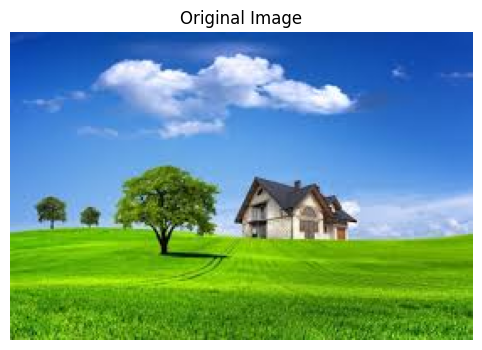

In [5]:
original_image = Image.open(image_path).convert("RGB")

print("Original image size:", original_image.size)

plt.figure(figsize=(6, 4))
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")
plt.savefig(images_folder / "tutorial_04_original_image.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Define Data Augmentation Operations

The tutorial includes operations such as:

- Rotation
- Shear
- Zoom
- Horizontal flip
- Brightness adjustment

In PyTorch/torchvision, these are implemented using `transforms`.


In [6]:
augmentation_transform = transforms.Compose([
    transforms.RandomRotation(degrees=40),
    transforms.RandomAffine(
        degrees=0,
        shear=20,
        scale=(0.8, 1.2)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=(0.5, 1.5),
        contrast=(0.8, 1.2),
        saturation=(0.8, 1.2)
    )
])

print(augmentation_transform)


Compose(
    RandomRotation(degrees=[-40.0, 40.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], scale=(0.8, 1.2), shear=[-20.0, 20.0])
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
)


## 5. Generate and Save 40 Augmented Images

This cell creates 40 augmented versions of the original image and saves them in the `augmented_images` folder.


In [7]:
num_augmented_images = 40
augmented_images = []

for i in range(num_augmented_images):
    augmented_image = augmentation_transform(original_image)
    augmented_images.append(augmented_image)

    output_path = save_folder / f"augmented_{i + 1:02d}.jpeg"
    augmented_image.save(output_path)

print(f"{num_augmented_images} augmented images saved in:")
print(save_folder.resolve())


40 augmented images saved in:
C:\Users\mumer\Downloads\T4\augmented_images


## 6. Display Some Augmented Images

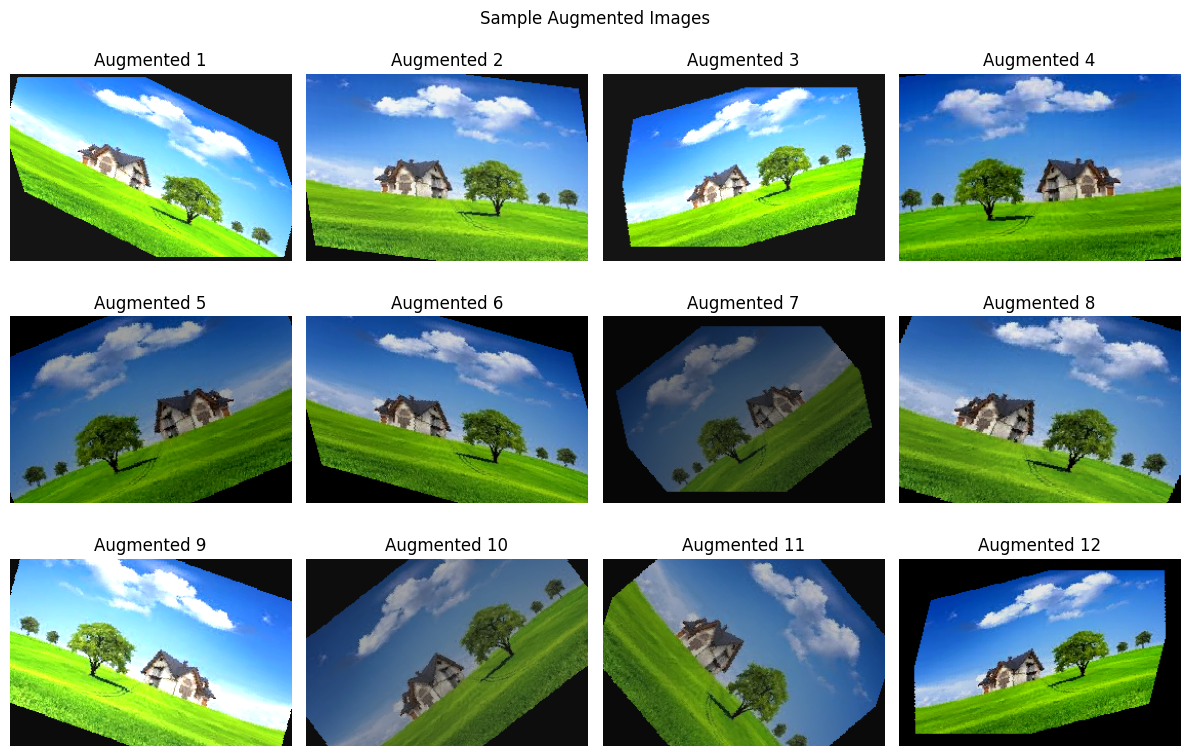

In [8]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(augmented_images[i])
    plt.title(f"Augmented {i + 1}")
    plt.axis("off")

plt.suptitle("Sample Augmented Images")
plt.tight_layout()
plt.savefig(images_folder / "tutorial_04_augmented_samples.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Compare Original and Augmented Images

This figure shows the original image beside some augmented versions.


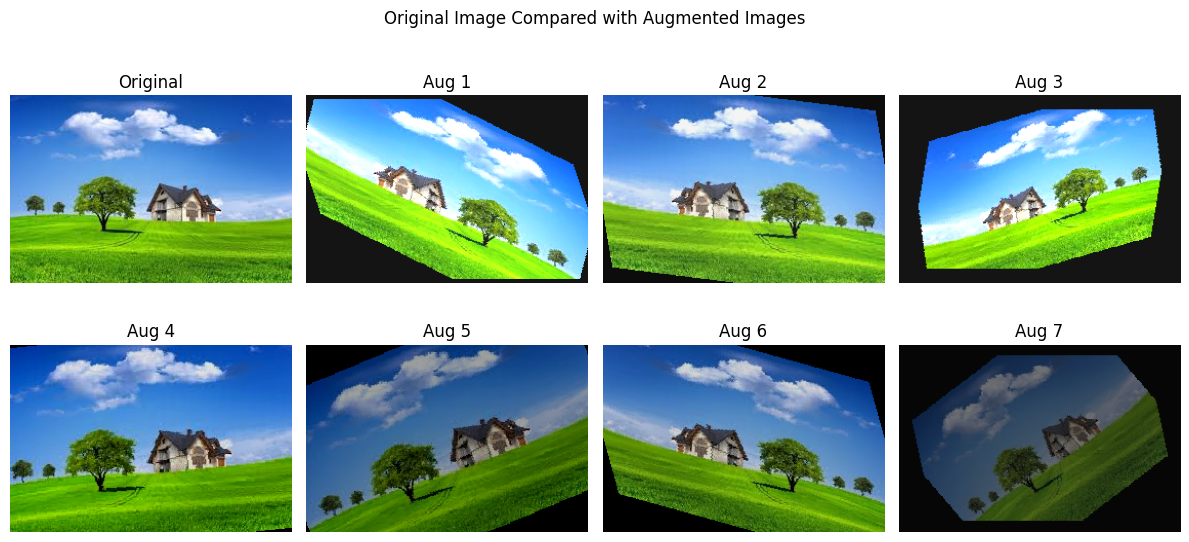

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

for i in range(7):
    plt.subplot(2, 4, i + 2)
    plt.imshow(augmented_images[i])
    plt.title(f"Aug {i + 1}")
    plt.axis("off")

plt.suptitle("Original Image Compared with Augmented Images")
plt.tight_layout()
plt.savefig(images_folder / "tutorial_04_original_vs_augmented.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Confirm Saved Files

In [10]:
saved_files = sorted(save_folder.glob("*.jpeg"))

print("Number of saved augmented images:", len(saved_files))
print("\nFirst 10 saved files:")

for file in saved_files[:10]:
    print(file)


Number of saved augmented images: 40

First 10 saved files:
augmented_images\augmented_01.jpeg
augmented_images\augmented_02.jpeg
augmented_images\augmented_03.jpeg
augmented_images\augmented_04.jpeg
augmented_images\augmented_05.jpeg
augmented_images\augmented_06.jpeg
augmented_images\augmented_07.jpeg
augmented_images\augmented_08.jpeg
augmented_images\augmented_09.jpeg
augmented_images\augmented_10.jpeg


# Final Observations

Data augmentation increases the variety of training images without collecting new data.

In this notebook, one original image was used to generate 40 augmented images.  
The transformations included rotation, shear, zoom, horizontal flipping, and brightness/contrast changes.

This helps create variations of the same image, which can improve the generalization ability of deep learning models.
